# Metacatalog VLSSR cross-match QA

Post-hoc QA against the VLSSR reference catalog at ~73 MHz (Blue band).

**Primary metric:** Blue-associated metacatalog completeness — fraction of rows with `"Blue" in bands_present` that match ≥1 VLSSR source within beam.

**Failure-mode metric:** VLSSR over-splitting — one VLSSR source matched by multiple metacatalog rows (possible LST/band over-split).

Matching uses primary metacatalog `RA`/`DEC` and `BMAJ_match` via `resolve_bmaj`, not Blue-band column positions.

**Run cells in order.**

In [1]:
from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, read_metacatalog, resolve_metacatalog_path
from lwa_catalog.analyze import (
    VlssrMatchConfig,
    match_catalog_to_vlssr,
    select_blue_associated_rows,
    summarize_vlssr_match,
)
from lwa_catalog.constants import DEFAULT_QUALITY_FLAG_MASK, VLSSR_DEFAULT_PATH

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband")  # existing fusion tree
VLSSR_PATH = VLSSR_DEFAULT_PATH  # override if VLSSR lives elsewhere
QUALITY_FLAG_MASK = DEFAULT_QUALITY_FLAG_MASK  # 247; set None to keep all rows
RUN_LST_MERGED_PASS = True  # optional ad-hoc pre-fusion check (not required for v1)

layout = CatalogLayout(CATALOG_DIR)
config = VlssrMatchConfig(catalog_path=VLSSR_PATH)

print("CATALOG_DIR =", layout.root.resolve())
print("metacatalog path =", resolve_metacatalog_path(layout))
print("QUALITY_FLAG_MASK =", QUALITY_FLAG_MASK)
print("VLSSR_PATH =", Path(VLSSR_PATH).resolve())
print("RUN_LST_MERGED_PASS =", RUN_LST_MERGED_PASS)

CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75
VLSSR_PATH = /fast/claw/vlssr_radecpeak.txt
RUN_LST_MERGED_PASS = True


## Load metacatalog

In [2]:
metacatalog = read_metacatalog(layout, quality_mask=QUALITY_FLAG_MASK)
blue_meta = select_blue_associated_rows(metacatalog)

print(f"metacatalog rows: {len(metacatalog)}")
print(f"Blue-associated rows: {len(blue_meta)}")
print(f"quality_flag present: {'quality_flag' in metacatalog.columns}")

metacatalog rows: 106426
Blue-associated rows: 102609


## Cross-match against VLSSR

In [3]:
result = match_catalog_to_vlssr(metacatalog, config=config)
print(summarize_vlssr_match(result))

LWA target rows:              102609
VLSSR footprint (Dec box):     92965
Meta matched (>=1 VLSSR):      68399
Blue completeness:            0.667
VLSSR matched (>=1 meta):      79088
VLSSR recovery:               0.851
VLSSR over-split (n_meta>1):   10097
Meta multi-VLSSR (n_vlssr>1):  16686
Max VLSSR hits per meta:          20


## Diagnostics

In [4]:
meta_flags = result.meta_flags
vlssr_flags = result.vlssr_flags

print("VLSSR hits per meta (value_counts):")
display(meta_flags["n_vlssr"].value_counts().sort_index())

print("\nIncomplete Blue-associated meta rows (no VLSSR match, first 20):")
display(meta_flags.loc[~meta_flags["matched"]].head(20))

oversplit_cols = [
    c
    for c in ["vlssr_pos", "RA", "DEC", "Peak_flux", "n_meta", "meta_ids", "oversplit"]
    if c in vlssr_flags.columns
]
print("\nOver-split VLSSR rows (multiple meta matches, first 20):")
display(vlssr_flags.loc[vlssr_flags["oversplit"], oversplit_cols].head(20))

VLSSR hits per meta (value_counts):


n_vlssr
0     34210
1     51713
2     12924
3      2982
4       614
5       110
6        30
7        13
8         2
9         3
10        1
11        1
13        1
14        1
15        2
16        1
20        1
Name: count, dtype: int64


Incomplete Blue-associated meta rows (no VLSSR match, first 20):


,meta_id,RA,DEC,n_vlssr,matched
1,0,50.957352,-37.270010,0,False
2,3,283.880459,1.421455,0,False
4,5,270.055735,-23.309410,0,False
7,52929,50.436023,-37.074669,0,False
10,52932,258.610079,-38.410699,0,False
12,52933,270.334609,-23.374664,0,False
16,16,265.089849,-30.958680,0,False
18,19,270.807016,-27.808885,0,False
21,52935,201.573236,-41.745320,0,False
27,52937,270.314452,-23.066678,0,False



Over-split VLSSR rows (multiple meta matches, first 20):


,vlssr_pos,RA,DEC,Peak_flux,n_meta,meta_ids,oversplit
22,22,0.079685,19.050247,0.896007,2,"[45175, 101126]",True
24,24,0.080179,27.659271,0.579359,2,"[18306, 76164]",True
44,44,0.116363,8.270123,0.542736,2,"[7114, 82288]",True
76,76,0.205521,32.935409,3.602827,2,"[8192, 74114]",True
78,78,0.212157,12.317341,0.685340,2,"[6568, 35301]",True
92,92,0.257089,41.822813,1.335390,2,"[541, 96996]",True
93,93,0.258257,27.597068,0.722256,2,"[18306, 76164]",True
101,101,0.278471,24.343903,0.454628,2,"[83896, 98110]",True
102,102,0.280003,23.882966,2.060833,2,"[6702, 54132]",True
109,109,0.307012,8.331698,2.089117,2,"[7114, 100284]",True


## VLSSR recovery vs peak flux

For each VLSSR `Peak_flux` threshold, recovery is the fraction of footprint VLSSR sources at or above that flux with ≥1 metacatalog match. The leftmost point equals the headline `vlssr_recovery` (0.668 for this catalog).

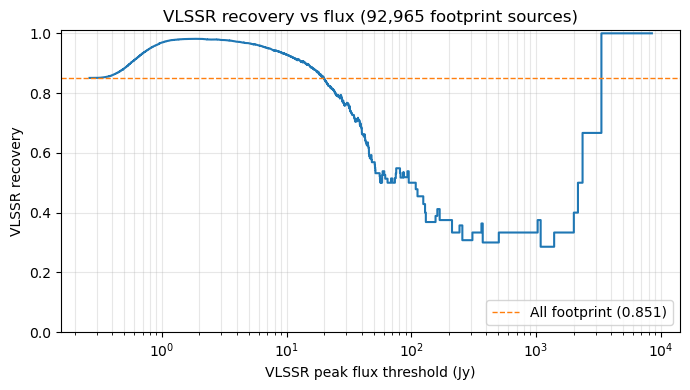

In [5]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

vlssr_flux = pd.to_numeric(vlssr_flags["Peak_flux"], errors="coerce")
vlssr_matched = vlssr_flags["n_meta"].gt(0)
ok = np.isfinite(vlssr_flux.to_numpy(dtype=float)) & (vlssr_flux > 0)

flux = vlssr_flux.loc[ok].to_numpy()
matched = vlssr_matched.loc[ok].astype(int).to_numpy()
order = np.argsort(flux)
flux = flux[order]
matched = matched[order]

suffix_matched = np.cumsum(matched[::-1])[::-1]
suffix_total = np.arange(len(flux), 0, -1, dtype=float)
recovery = suffix_matched / suffix_total
overall_recovery = float(result.summary["vlssr_recovery"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(flux, recovery, drawstyle="steps-post")
ax.axhline(
    overall_recovery,
    color="C1",
    ls="--",
    lw=1,
    label=f"All footprint ({overall_recovery:.3f})",
)
ax.set_xscale("log")
ax.set_xlabel("VLSSR peak flux threshold (Jy)")
ax.set_ylabel("VLSSR recovery")
ax.set_ylim(0, 1.01)
ax.set_title(f"VLSSR recovery vs flux ({len(flux):,} footprint sources)")
ax.legend(loc="lower right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## Optional: LST-merged Blue pass

Ad-hoc pre-fusion check. Not required for v1 sign-off. Set `RUN_LST_MERGED_PASS = True` in the config cell.

In [6]:
if RUN_LST_MERGED_PASS:
    from lwa_catalog.io import read_lst_merged

    lst_blue = read_lst_merged(layout, "Blue")
    lst_config = VlssrMatchConfig(catalog_path=VLSSR_PATH, target="lst_merged_blue")
    lst_result = match_catalog_to_vlssr(lst_blue, config=lst_config)
    print("LST-merged Blue pass:")
    print(summarize_vlssr_match(lst_result))
else:
    print("Skipping LST-merged Blue pass (RUN_LST_MERGED_PASS=False)")

LST-merged Blue pass:
LWA target rows:              105136
VLSSR footprint (Dec box):     92965
Meta matched (>=1 VLSSR):      66099
Blue completeness:            0.629
VLSSR matched (>=1 meta):      73623
VLSSR recovery:               0.792
VLSSR over-split (n_meta>1):     189
Meta multi-VLSSR (n_vlssr>1):   6808
Max VLSSR hits per meta:          12
